In [6]:
import pandas as pd

df = pd.read_csv("./normalized_landmark_data.csv")
X = df.drop(columns=["Video_Filename", "frame", "label"])  # 136D normalized features
y = df["label"]

In [7]:
#!pip install scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

y_pred = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accuracy: 0.8716814159292036
[[ 73  18]
 [ 11 124]]
              precision    recall  f1-score   support

           0       0.87      0.80      0.83        91
           1       0.87      0.92      0.90       135

    accuracy                           0.87       226
   macro avg       0.87      0.86      0.86       226
weighted avg       0.87      0.87      0.87       226



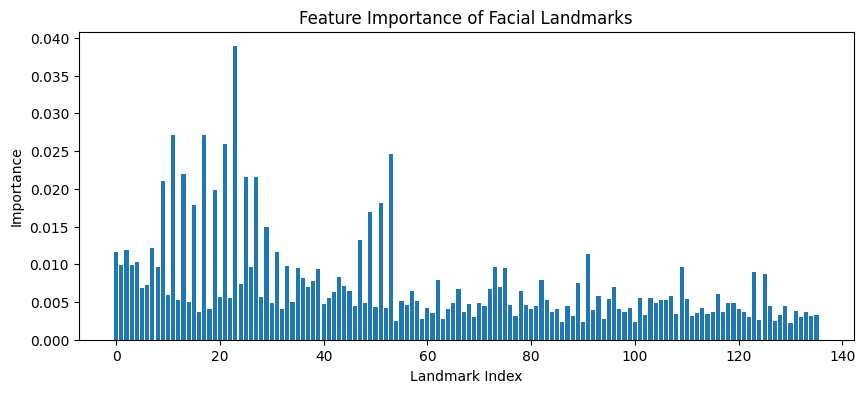

In [8]:
import matplotlib.pyplot as plt

importances = clf.feature_importances_
plt.figure(figsize=(10, 4))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance of Facial Landmarks")
plt.xlabel("Landmark Index")
plt.ylabel("Importance")
plt.show()


In [16]:
!pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/29/22/e3ff2dfafe862a91733dfa0aecdb4794aa1d9a18e09a14e118bde0cbc2db/xgboost-3.0.2-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/150.0 MB 325.1 kB/s eta 0:07:42
   ---------------------------------------- 0.1/150.0 MB 375.8 kB/s eta 0:06:39
   ---------------------------------------- 0.3/150.0 MB 1.6 MB/s eta 0:01:32
   ---------------------------------------- 1.2/150.0 MB 6.3 MB/s eta 0:00:24
   - -------------------------------------- 3.9/150.0 MB 16.8 MB/s eta 0:00:09
   - -------------------------------------- 7.3/150.0 MB 24.5 MB/s eta 0:00:06
   -- ------------------------------------- 10.0/150.0 MB 29.2 MB/s eta 0:00:05
   --- ---------------------


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = df.drop(columns=["Video_Filename", "frame", "label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[ 79  12]
 [ 12 123]]
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        91
           1       0.91      0.91      0.91       135

    accuracy                           0.89       226
   macro avg       0.89      0.89      0.89       226
weighted avg       0.89      0.89      0.89       226



In [10]:
import joblib

joblib.dump(clf, "rf_face_model.pkl")
model.save_model("xgb_face_model.json")